In [1]:
import os
import time
import copy
from random import shuffle

import cv2
from PIL import Image
import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import tqdm.notebook as tqdm

import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
import albumentations as albu


def get_transforms():
    max_pixel_value = 1.0
    mean = [0.5]
    std = [0.5]

    train_ops = []
    # if 'hflip' in opt.augs:
    train_ops.append(albu.HorizontalFlip(p=0.5))
    # if 'vflip' in opt.augs:
    train_ops.append(albu.VerticalFlip(p=0.1))
    # if 'shift_scale_rotate' in opt.augs:
    train_ops.append(albu.ShiftScaleRotate(scale_limit=0.1, rotate_limit=10, shift_limit=0.07, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=0))

    data_transforms = {
        'train': albu.Compose(
            [
                *train_ops,
                albu.Resize(256, 256, cv2.INTER_LINEAR),
            ]
        ),
        'val': albu.Compose(
            [
                albu.Resize(256, 256, cv2.INTER_LINEAR),
            ]
        ),
    }
    return data_transforms


data_transforms = get_transforms()

In [32]:
from src.datasets.kits_dataset import KITSDataset

root_dir = "/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/kits23/dataset"
split_dir = "/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/data/kits"
split = 'val'
transforms = data_transforms['val']
scan_params = {
    'load_masks': True,
    'norm_scheme': {
        'kind': 'ct',
        'rescale': True,
        'fingerprint_path': '/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/configs/classification/kits_tumours/dataset_fingerprint_fg_tumor.json',
    },
    'slicing_direction': 'axial',
    'classes': ['empty', 'kidney', 'tumor', 'cyst'],
    'sampling_class': ['tumor'],
    'classify_labels': ['tumor'],
    'classify_labels_thresh': 1000,
    'filter_class_slices': ['kidney'],
    'filter_class_slices_thresh': 100,
}
val_data = KITSDataset(root_dir, split, split_dir=split_dir, transforms=transforms, **scan_params)
print(len(val_data))

print(val_data[0]["image"].shape)
print(list(val_data[0].keys()))
print(val_data[0]['label'])

6216
torch.Size([1, 256, 256])
['image', 'masks', 'label', 'scan_name', 'scan_casename', 'slice_index']
tensor(0)


In [129]:
rng = torch.Generator()
rng.manual_seed(42)
test_loader = torch.utils.data.DataLoader(
    val_data,
    batch_size=1,
    shuffle=False,
    pin_memory=True,
    num_workers=0,
    generator=rng,
)

In [134]:
from src.models.classifier import ClassificationModel
from easydict import EasyDict as edict

model_config = {
    "kind": "efficientnet_v2_s",
    "n_classes": 1,
    "pretrained": True,
    "in_channels": 1,
    "loss": "bce",
    "lr": 0.0003,
    "b1": 0.9,
    "b2": 0.999,
    "weight_decay": 0.0001,
}
model_config = edict(model_config)
model = ClassificationModel(opt=model_config, img_size=[256, 256])

# Load the state dictionary
state_dict_path = '/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/tools/training_logs/classification/kits_tumours/efficientnet_v2_s-September-15-2024_07+55PM-kits_effv2s_aug/checkpoints/checkpoint_980.pth'
state_dict = torch.load(state_dict_path)
model.load_state_dict(state_dict['model'])
model.eval()

ClassificationModel(
  (model): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(1, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): FusedMBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): FusedMBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (1): BatchN

In [131]:
from torchmetrics import F1Score, MetricCollection, Precision, Recall

device = torch.device("cuda")

task = 'binary'
metric_list = [
    Precision(num_classes=1, task=task, average='macro'),
    Recall(num_classes=1, task=task, average='macro'),
    F1Score(num_classes=1, task=task, average='macro'),
]
train_metrics = MetricCollection(metric_list).to(device)

In [135]:
import torch.nn.functional as F

train_metrics.reset()
with torch.no_grad():
    for idx, batch in enumerate(test_loader):
        # print(f"name: {batch['scan_casename'][0]}_slice{batch['slice_index'][0]}")
        batch = {k: batch[k].to(device) for k in {'image', 'label', 'masks'}}
        _, pred = model(batch).values()
        prob = F.sigmoid(pred)

        # print(f"label: {batch['label'].item()}, prob: {round(prob.item(),2)}")
        # if batch['label'].item() == round(prob.item(),2):
        #     print(f"Correct prediction")
        train_metrics.update(prob, batch['label'])
        if idx >= 1000:
            metrics = train_metrics.compute()
            print(metrics)
            break

{'BinaryPrecision': tensor(0.8594, device='cuda:0'), 'BinaryRecall': tensor(0.8730, device='cuda:0'), 'BinaryF1Score': tensor(0.8661, device='cuda:0')}


torch.Size([1, 4, 256, 256])
tensor(1, device='cuda:0', dtype=torch.uint8)


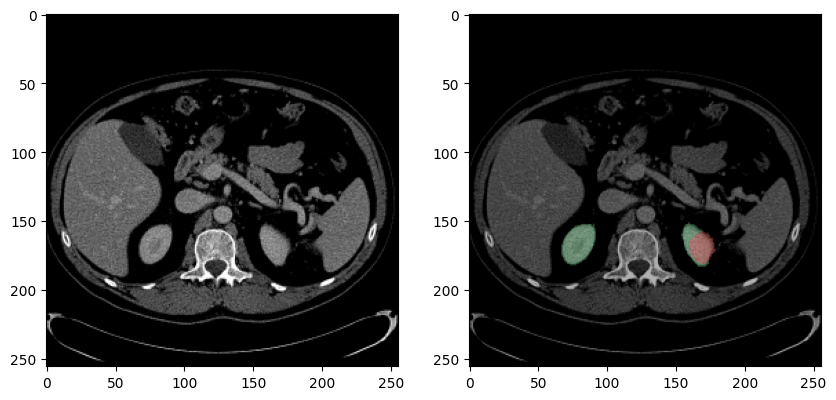

In [136]:
# {'BinaryPrecision': tensor(0.9286, device='cuda:0'), 'BinaryRecall': tensor(0.8298, device='cuda:0'), 'BinaryF1Score': tensor(0.8764, device='cuda:0')}
from src.visualizations import CLASS_COLORS, DEFAULT_COLOR

batch['image'].shape
print(batch['masks'].shape)
print(batch['masks'].max())
classes = ['empty', 'kidney', 'tumor', 'cyst']
s = {k: batch[k].squeeze(0).cpu() for k in {'image', 'masks'}}
img = ((s['image'][0].cpu().numpy() + 1) / 2) * 255
img = np.stack([img.astype(np.uint8)] * 3, -1)
alpha = 0.7
vis_mask = np.zeros((*s['masks'].shape[1:], 3), dtype=np.uint8)
for j in range(1, s['masks'].shape[0]):
    # print(s['masks'].shape, dataset.classes)
    class_name = classes[j]

    color = CLASS_COLORS.get(class_name, DEFAULT_COLOR)
    # print(class_name, color)
    cl_mask = np.stack([s['masks'][j].numpy()] * 3, -1).astype(np.uint8) * np.array(color).reshape(1, 1, 3)
    vis_mask = vis_mask + cl_mask
vis_mask = vis_mask.astype(np.uint8)
# print(f'image shape: {img.shape}, mask shape: {vis_mask.shape}')
# print(f"image range: {img.min(), img.max()}, mask range: {s['masks'].min(), s['masks'].max()}")
vis_img = (img * alpha).astype(np.uint8) + ((1 - alpha) * vis_mask).astype(np.uint8)  # blended image

fig, ax = plt.subplots(1, 2, figsize=(10, 10))
ax[0].imshow(img, cmap='gray')
ax[1].imshow(vis_img)

I have taken correct propositions of data from each classes while staging my data to avoid overfitted results. Medical Image Datasets will always be like this, we don't have enough data on victim rather we have so many healthy ones. That is what we called is a "Skewed Dataset", obviously we developed methods to approach those problems (like K-Fold Cross Validation) that will explain that in my next notebook.